In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import polars as pl
from matplotlib import pyplot as plt

from ethos.constants import PROJECT_ROOT
from ethos.constants import SpecialToken as ST
from ethos.inference.constants import Task
from ethos.metrics import compute_and_print_metrics, preprocess_inference_results
from ethos.utils import get_mimic_hf_patients

# Requires original MIMIC-IV 2.2 dataset that we do not provide
result_dir = PROJECT_ROOT / "results" / Task.READMISSION
# heart_failure_cohort = get_mimic_hf_patients(PROJECT_ROOT / "data/mimic-2.2")

/home/henri/ethos-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Find project root by looking for pyproject.toml
import sys
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
from src.ethos.datasets.readmission import ReadmissionDatasetNew
path = "../../../../mnt/data_share/project_henri/ethos-ares/mimic-tokenized/test"
dataset = ReadmissionDatasetNew(path)

Found 64594 discharge tokens before removing those preceded by death.
Found 63348 discharge tokens after removing those preceded by death.


In [3]:
def compute_readmission_results(input_dir: Path, outcome_tokens: list[str]) -> pl.DataFrame:
    # outcome_tokens = [str(st) for st in outcome_tokens]
    return preprocess_inference_results(
        input_dir,
        actual_expr=pl.col("actual").is_in(outcome_tokens),
        expected_expr=(
            pl.col("expected").is_in(outcome_tokens)
            & (pl.col("true_token_time") <= pl.duration(days=30))
        ),
    )


def evaluate_readmission_results(input_dir: Path) -> dict:
    # df = compute_readmission_results(input_dir, outcome_tokens=[ST.ADMISSION, ST.DEATH])
    df = compute_readmission_results(input_dir, outcome_tokens=[ST.ADMISSION])

    fig = plt.figure(figsize=(5, 5))
    rep_num = df["counts"].mean()
    fig.suptitle(f"30-Day Readmission (rep_num={rep_num:.2f})\n{input_dir.name}")

    plt.subplot(1, 1, 1)
    res_full = compute_and_print_metrics(df["expected"], df["actual"], "Full")

    # Here, we leave samples where the history (gt) spans for 30 days
    '''reduced_df = df.filter(
        (pl.col("expected") == 1)
        | ((pl.col("expected") == 0) & (pl.col("true_token_time") >= pl.duration(days=30)))
    )
    plt.subplot(1, 3, 2)
    res_reduced = compute_and_print_metrics(reduced_df["expected"], reduced_df["actual"], "Reduced")'''

    # plt.subplot(1, 3, 3)
    '''hearth_failure_df = df.filter(pl.col("patient_id").is_in(heart_failure_cohort))
    res_hf = compute_and_print_metrics(
        hearth_failure_df["expected"], hearth_failure_df["actual"], "HF patients"
    )'''

    return {
        "name": input_dir.name,
        "auc_full": res_full["fitted_auc"],
        # "auc_reduced": res_reduced["fitted_auc"],
        # "auc_hf": res_hf["fitted_auc"],
        "rep_num": rep_num,
    }

/home/henri/ethos-benchmark/src/ethos/metrics.py:172: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  precision_values = np.divide(tpr_values * positives, denominator, where=more_than_zero)


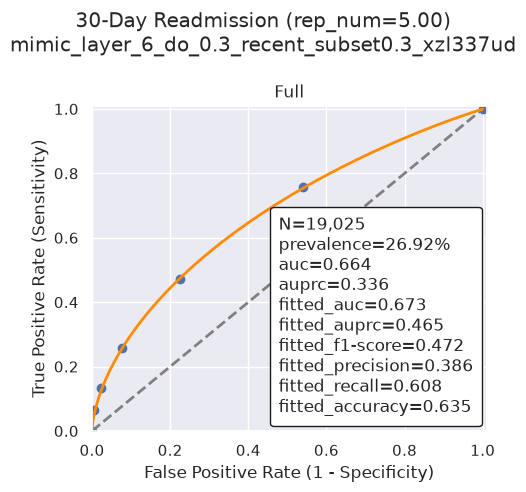

In [4]:
readmission_results = []
for result_fp in result_dir.iterdir():
    readmission_results.append(evaluate_readmission_results(result_fp))
    plt.tight_layout()
readmission_results = pl.from_dicts(readmission_results).sort("auc_full", descending=True)

In [ ]:
readmission_results.sort("auc_full", descending=True)